<a href="https://colab.research.google.com/github/kvlaskarolina/JU-sem6-IAI/blob/main/04_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [5]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.family": "serif",
    'mathtext.fontset': 'dejavuserif'
})

# Zadanie I
- Zaimplementuj dowolną (w miarę prostą) funckję analityczną $f: \mathbb{R}^2 \to \mathbb{R}$ w **numpy** (na przykład $f(x_0, x_1) = x_0^2 + x_1^2$)
- Zaimplementuj gradient funkcji $\nabla_{(x_0, x_1)}f(x_0, x_1): \mathbb{R} \to \mathbb{R}^2$.
- Zaimplementuj metodę gradientu spadkowego na $f$ z użyciem powyższych funkcji.
- Zwizualizuj powieżchnię $f$ za pomocą **imshow** oraz trajektorię gradientu za pomocą **plot**.

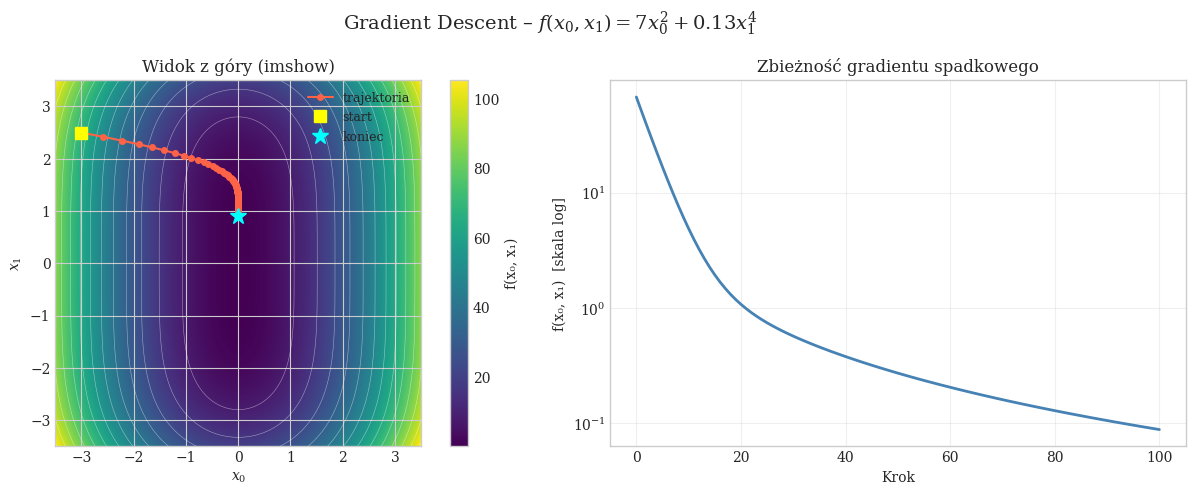

In [6]:
def f(x0: float, x1: float) -> float:
    return 7 * x0**2 + 0.13 * x1**4

def grad_f(x0: float, x1: float) -> np.ndarray:
    return np.array([14.0 * x0, 4 * 0.13 * x1**3])

def gradient_descent(
    f, grad_f,
    x0_init: float,
    x1_init: float,
    lr: float = 0.01,
    n_steps: int = 100,
    tol: float = 1e-8,
) -> list[tuple[float, float, float]]:
    x = np.array([x0_init, x1_init], dtype=float)
    trajectory = [(x[0], x[1], f(x[0], x[1]))]

    for _ in range(n_steps):
        g = grad_f(x[0], x[1])
        x = x - lr * g
        val = f(x[0], x[1])
        trajectory.append((x[0], x[1], val))
        if np.linalg.norm(g) < tol:
            break

    return trajectory


# ---------------------------------------------

def plot_surface_and_trajectory(f, trajectory, grid_range=3.5, resolution=300):
    xs = np.linspace(-grid_range, grid_range, resolution)
    X0, X1 = np.meshgrid(xs, xs)
    Z = f(X0, X1)

    path_x0 = [p[0] for p in trajectory]
    path_x1 = [p[1] for p in trajectory]
    fvals   = [p[2] for p in trajectory]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(r"Gradient Descent – $f(x_0, x_1) = 7x_0^2 + 0.13x_1^4$", fontsize=14)

    ax = axes[0]
    im = ax.imshow(Z, origin="lower",
                   extent=[-grid_range, grid_range, -grid_range, grid_range],
                   cmap="viridis", aspect="equal")
    plt.colorbar(im, ax=ax, label="f(x₀, x₁)")
    ax.contour(X0, X1, Z, levels=14, colors="white", linewidths=0.4, alpha=0.5)
    ax.plot(path_x0, path_x1, "o-", color="tomato", markersize=4,
            linewidth=1.5, label="trajektoria")
    ax.plot(path_x0[0],  path_x1[0],  "s", color="yellow", markersize=8, label="start")
    ax.plot(path_x0[-1], path_x1[-1], "*", color="cyan",   markersize=12, label="koniec")
    ax.set_xlabel("$x_0$"); ax.set_ylabel("$x_1$")
    ax.set_title("Widok z góry (imshow)")
    ax.legend(fontsize=9)

    ax2 = axes[1]
    if all(v > 0 for v in fvals):
        ax2.semilogy(fvals, color="steelblue", linewidth=2)
        ax2.set_ylabel("f(x₀, x₁)  [skala log]")
    else:
        ax2.plot(fvals, color="steelblue", linewidth=2)
        ax2.set_ylabel("f(x₀, x₁)")
    ax2.set_xlabel("Krok")
    ax2.set_title("Zbieżność gradientu spadkowego")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
# ---------------------------------------------

traj = gradient_descent(f, grad_f, x0_init=-3.0, x1_init=2.5, lr=0.01, n_steps=100)
plot_surface_and_trajectory(f, traj)

# Zadanie II
- Zaimplementuj bardziej skomplikowaną funkcję analityczną $f$ przy użyciu **PyTorch**.
- Użyj *torch.grad* do automatycznego obliczenia gradientu.
- Zaimplementuj optymalizator momentum (patrz wykład).
- Zwizualizuj podobnie do Zadania I.
- Zwizualizuj efekt parametru $\beta$ na trajektorię optymalizacji.

Start: (-1.5, 2.5),  lr=0.01,  kroki=300

β=0.00  →  końcowe (0.4703, 0.2113),  f=0.731768
β=0.50  →  końcowe (0.4658, 0.2071),  f=0.737215
β=0.90  →  końcowe (0.5345, 0.2721),  f=0.646142
β=0.99  →  końcowe (0.3719, 0.0845),  f=0.866160


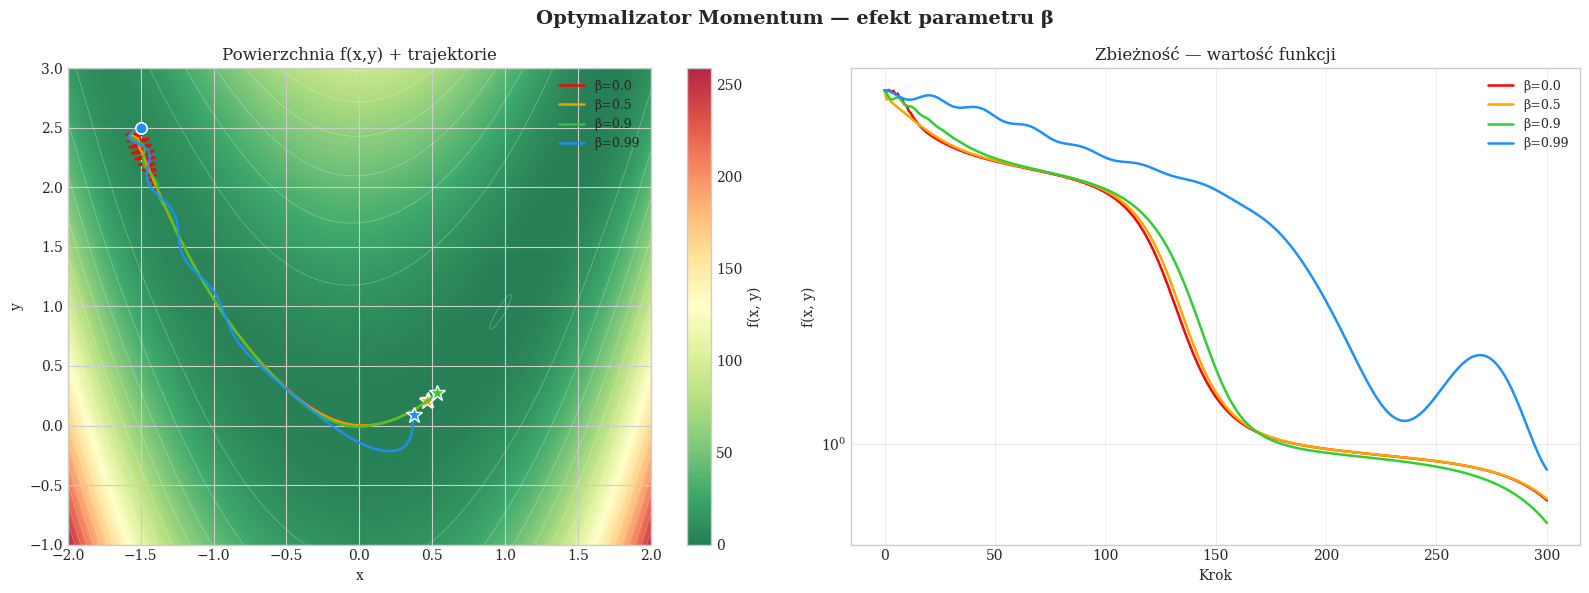

In [7]:
import matplotlib.pyplot as plt

def f(x, y):
    rosenbrock = (1 - x)**2 + 10 * (y - x**2)**2
    perturbation = torch.sin(3 * x) * torch.cos(2 * y)
    return rosenbrock + 0.5 * perturbation


def compute_gradient(x, y):
    x = x.clone().detach().requires_grad_(True)
    y = y.clone().detach().requires_grad_(True)
    loss = f(x, y)
    loss.backward()
    return x.grad.clone(), y.grad.clone()


def momentum_optimizer(x0, y0, lr=0.001, beta=0.9, n_steps=200):
    x = torch.tensor([x0], dtype=torch.float32)
    y = torch.tensor([y0], dtype=torch.float32)

    vx = torch.zeros(1)
    vy = torch.zeros(1)

    trajectory = [(x.item(), y.item())]

    for _ in range(n_steps):
        gx, gy = compute_gradient(x, y)

        vx = beta * vx + (1 - beta) * gx
        vy = beta * vy + (1 - beta) * gy

        x = x - lr * vx
        y = y - lr * vy

        trajectory.append((x.item(), y.item()))

    return trajectory



# rysowanie --------------------------------------------------------------------------------------------------------------------------------------------------------
def plot_surface_and_trajectories(trajectories_dict, x_range=(-2, 2), y_range=(-1, 3)):
    # Siatka do imshow
    res = 400
    xs = np.linspace(*x_range, res)
    ys = np.linspace(*y_range, res)
    X, Y = np.meshgrid(xs, ys)

    X_t = torch.tensor(X, dtype=torch.float32)
    Y_t = torch.tensor(Y, dtype=torch.float32)
    Z = f(X_t, Y_t).numpy()

    colors = ['red', 'orange', 'limegreen', 'dodgerblue']
    betas  = list(trajectories_dict.keys())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Optymalizator Momentum — efekt parametru β", fontsize=14, fontweight='bold')

    ax = axes[0]
    im = ax.imshow(
        Z,
        extent=[*x_range, *y_range],
        origin='lower',
        cmap='RdYlGn_r',
        aspect='auto',
        alpha=0.85
    )
    plt.colorbar(im, ax=ax, label='f(x, y)')

    ax.contour(X, Y, Z, levels=20, colors='white', linewidths=0.4, alpha=0.4)

    for (beta, traj), color in zip(trajectories_dict.items(), colors):
        tx = [p[0] for p in traj]
        ty = [p[1] for p in traj]
        ax.plot(tx, ty, '-', color=color, linewidth=1.8, label=f'β={beta}', alpha=0.9)
        ax.plot(tx[0],  ty[0],  'o', color=color, markersize=8, markeredgecolor='white')
        ax.plot(tx[-1], ty[-1], '*', color=color, markersize=12, markeredgecolor='white')

    ax.set_xlim(x_range)
    ax.set_ylim(y_range)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title('Powierzchnia f(x,y) + trajektorie')
    ax.legend(loc='upper right', fontsize=9)

    ax2 = axes[1]
    for (beta, traj), color in zip(trajectories_dict.items(), colors):
        losses = [
            f(torch.tensor([p[0]]), torch.tensor([p[1]])).item()
            for p in traj
        ]
        ax2.plot(losses, color=color, linewidth=1.8, label=f'β={beta}')

    ax2.set_xlabel('Krok')
    ax2.set_ylabel('f(x, y)')
    ax2.set_title('Zbieżność — wartość funkcji')
    ax2.set_yscale('log')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
# rysowanie --------------------------------------------------------------------------------------------------------------------------------------------------------

if __name__ == "__main__":
    x0, y0   = -1.5, 2.5
    lr       = 0.01
    n_steps  = 300
    betas    = [0.0, 0.5, 0.9, 0.99]

    print(f"Start: ({x0}, {y0}),  lr={lr},  kroki={n_steps}\n")

    trajectories = {}
    for beta in betas:
        traj = momentum_optimizer(x0, y0, lr=lr, beta=beta, n_steps=n_steps)
        final = traj[-1]
        loss  = f(torch.tensor([final[0]]), torch.tensor([final[1]])).item()
        print(f"β={beta:.2f}  →  końcowe ({final[0]:.4f}, {final[1]:.4f}),  f={loss:.6f}")
        trajectories[beta] = traj

    plot_surface_and_trajectories(trajectories)